1 cargamos la imagen 


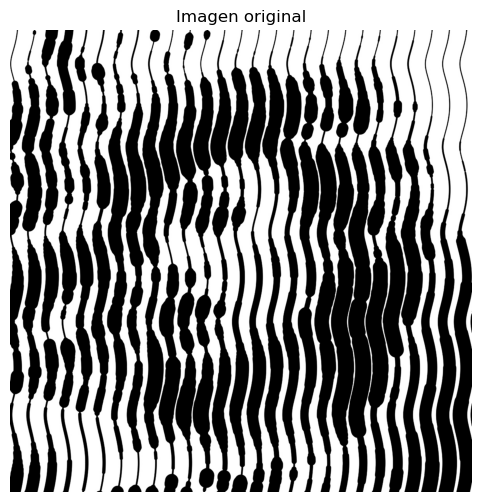

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
img = cv2.imread('combinacion-m-a.jpg', 0)

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

2- Provocamos el aliasing 

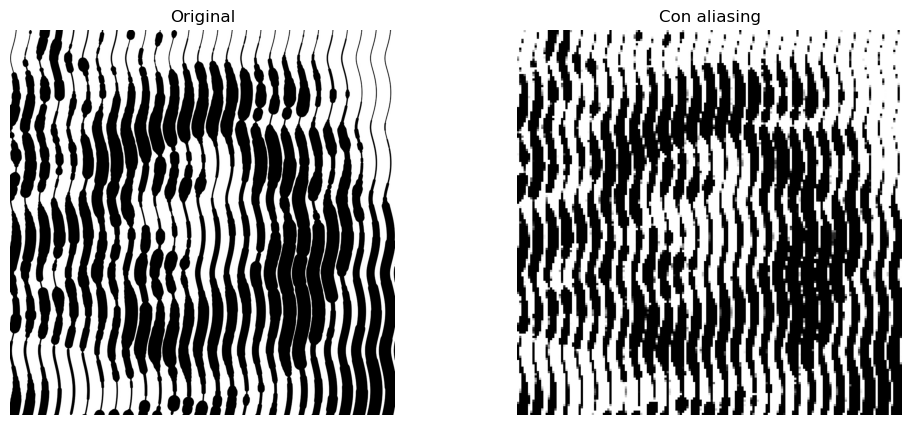

In [2]:
# Reducir mucho la imagen
small = cv2.resize(img, (img.shape[1]//8, img.shape[0]//8), interpolation=cv2.INTER_NEAREST)

# Volver a agrandar
aliasing_img = cv2.resize(small, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(aliasing_img, cmap='gray')
plt.title('Con aliasing')
plt.axis('off')

plt.show()

3- Reducimos  el aliasing

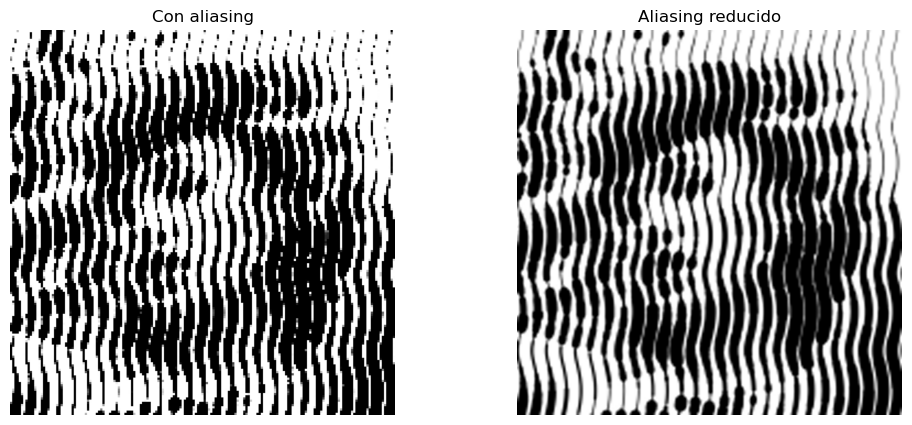

In [3]:
blur = cv2.GaussianBlur(img, (5,5), 0)

small_good = cv2.resize(blur, (img.shape[1]//8, img.shape[0]//8), interpolation=cv2.INTER_AREA)
restored = cv2.resize(small_good, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(aliasing_img, cmap='gray')
plt.title('Con aliasing')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(restored, cmap='gray')
plt.title('Aliasing reducido')
plt.axis('off')

plt.show()

4- Simulamos moire

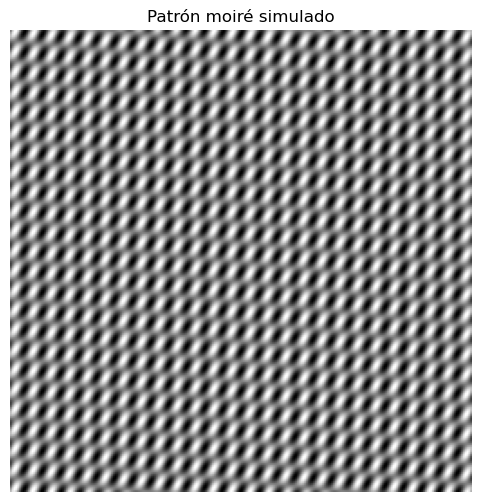

In [4]:
x = np.arange(0, 256)
y = np.arange(0, 256)
X, Y = np.meshgrid(x, y)

patron1 = 127 + 127*np.sin(2*np.pi*X/10)
patron2 = 127 + 127*np.sin(2*np.pi*(X+Y)/11)

moire = ((patron1 + patron2) / 2).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(moire, cmap='gray')
plt.title('Patrón moiré simulado')
plt.axis('off')
plt.show()

5- Reduccion de moire

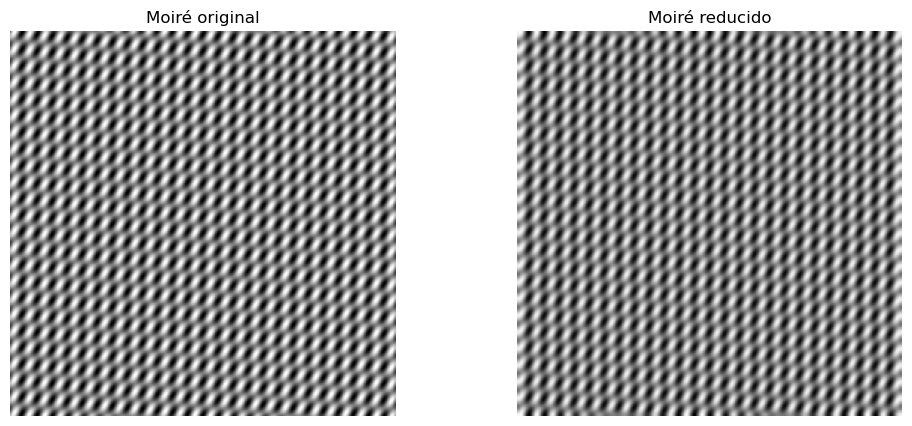

In [5]:
moire_suave = cv2.GaussianBlur(moire, (7,7), 0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(moire, cmap='gray')
plt.title('Moiré original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(moire_suave, cmap='gray')
plt.title('Moiré reducido')
plt.axis('off')

plt.show()

6- Kernels diagonales 

primero \

In [6]:
kernel_diag1 = np.array([
    [ 2, -1, -1],
    [-1,  2, -1],
    [-1, -1,  2]
], dtype=np.float32)

segundo /

In [7]:
kernel_diag2 = np.array([
    [-1, -1,  2],
    [-1,  2, -1],
    [ 2, -1, -1]
], dtype=np.float32)

7 aplicamos convolucion diagonal 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Leer imagen
img = cv2.imread('colores.jpeg', 0)

# 1. Reducir moiré / aliasing con suavizado
img_suave = cv2.GaussianBlur(img, (5,5), 0)

# 2. Kernels diagonales
kernel_diag1 = np.array([
    [ 2, -1, -1],
    [-1,  2, -1],
    [-1, -1,  2]
], dtype=np.float32)

kernel_diag2 = np.array([
    [-1, -1,  2],
    [-1,  2, -1],
    [ 2, -1, -1]
], dtype=np.float32)

# 3. Aplicar convolución
resp_diag1 = convolve2d(img_suave, kernel_diag1, mode='same', boundary='symm')
resp_diag2 = convolve2d(img_suave, kernel_diag2, mode='same', boundary='symm')

# 4. Mostrar
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(img_suave, cmap='gray')
plt.title('Suavizada')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(resp_diag1, cmap='gray')
plt.title('Diagonal \\')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(resp_diag2, cmap='gray')
plt.title('Diagonal /')
plt.axis('off')

plt.show()

ModuleNotFoundError: No module named 'scipy'

con SCIPY

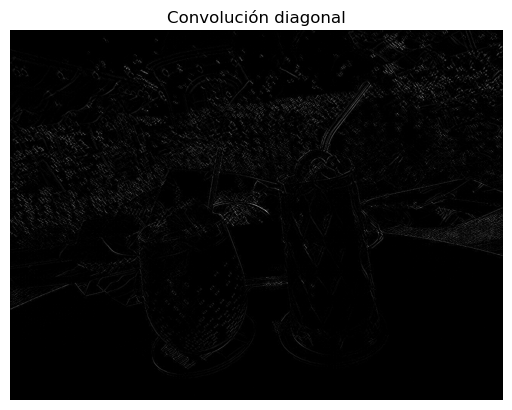

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('colores.jpeg', 0)

# Kernel diagonal
kernel = np.array([
    [ 2, -1, -1],
    [-1,  2, -1],
    [-1, -1,  2]
], dtype=np.float32)

# Aplicar convolución
resultado = cv2.filter2D(img, -1, kernel)

plt.imshow(resultado, cmap='gray')
plt.title('Convolución diagonal')
plt.axis('off')
plt.show()